# Movie Budget, Box Office & ROI Analysis



# Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

file_name = r"C:\Users\29281\Desktop\movies_metadata_box_office.csv"

df = pd.read_csv(file_name, usecols=['id', 'budget', 'revenue', 'release_date', 'release_year'])
print(f" Data Loaded: {file_name} | Total Rows: {len(df)}")


df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year


df_final = df.dropna(subset=['budget', 'release_year', 'revenue']).copy()

df_final['budget_M'] = df_final['budget'] / 1_000_000
df_final['revenue_M'] = df_final['revenue'] / 1_000_000


df_final['ROI_pct'] = ((df_final['revenue'] - df_final['budget']) / df_final['budget']) * 100

df_final['profit_M'] = df_final['revenue_M'] - df_final['budget_M']


df_analysis = df_final[df_final['release_year'] >= 1950].copy()

df_analysis['budget_bin'] = pd.cut(df_analysis['budget_M'], bins=10, labels=False)

budget_mid = df_analysis.groupby('budget_bin')['budget_M'].median().reset_index()

print(f" Valid Budget-Revenue-ROI Analysis Samples: {len(df_analysis)} movies")
print(f" Overall Average ROI: {df_analysis['ROI_pct'].mean():.2f}%")
print(f" Overall Median ROI: {df_analysis['ROI_pct'].median():.2f}%")




FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\29281\\Desktop\\movies_metadata_box_office.csv'

## 1. Movie Budget Distribution (≤ $100M)
**Key Insight**: Strongly right-skewed; **75% of budgets ≤ $40M**. Low-budget films dominate, big-budget films are rare.

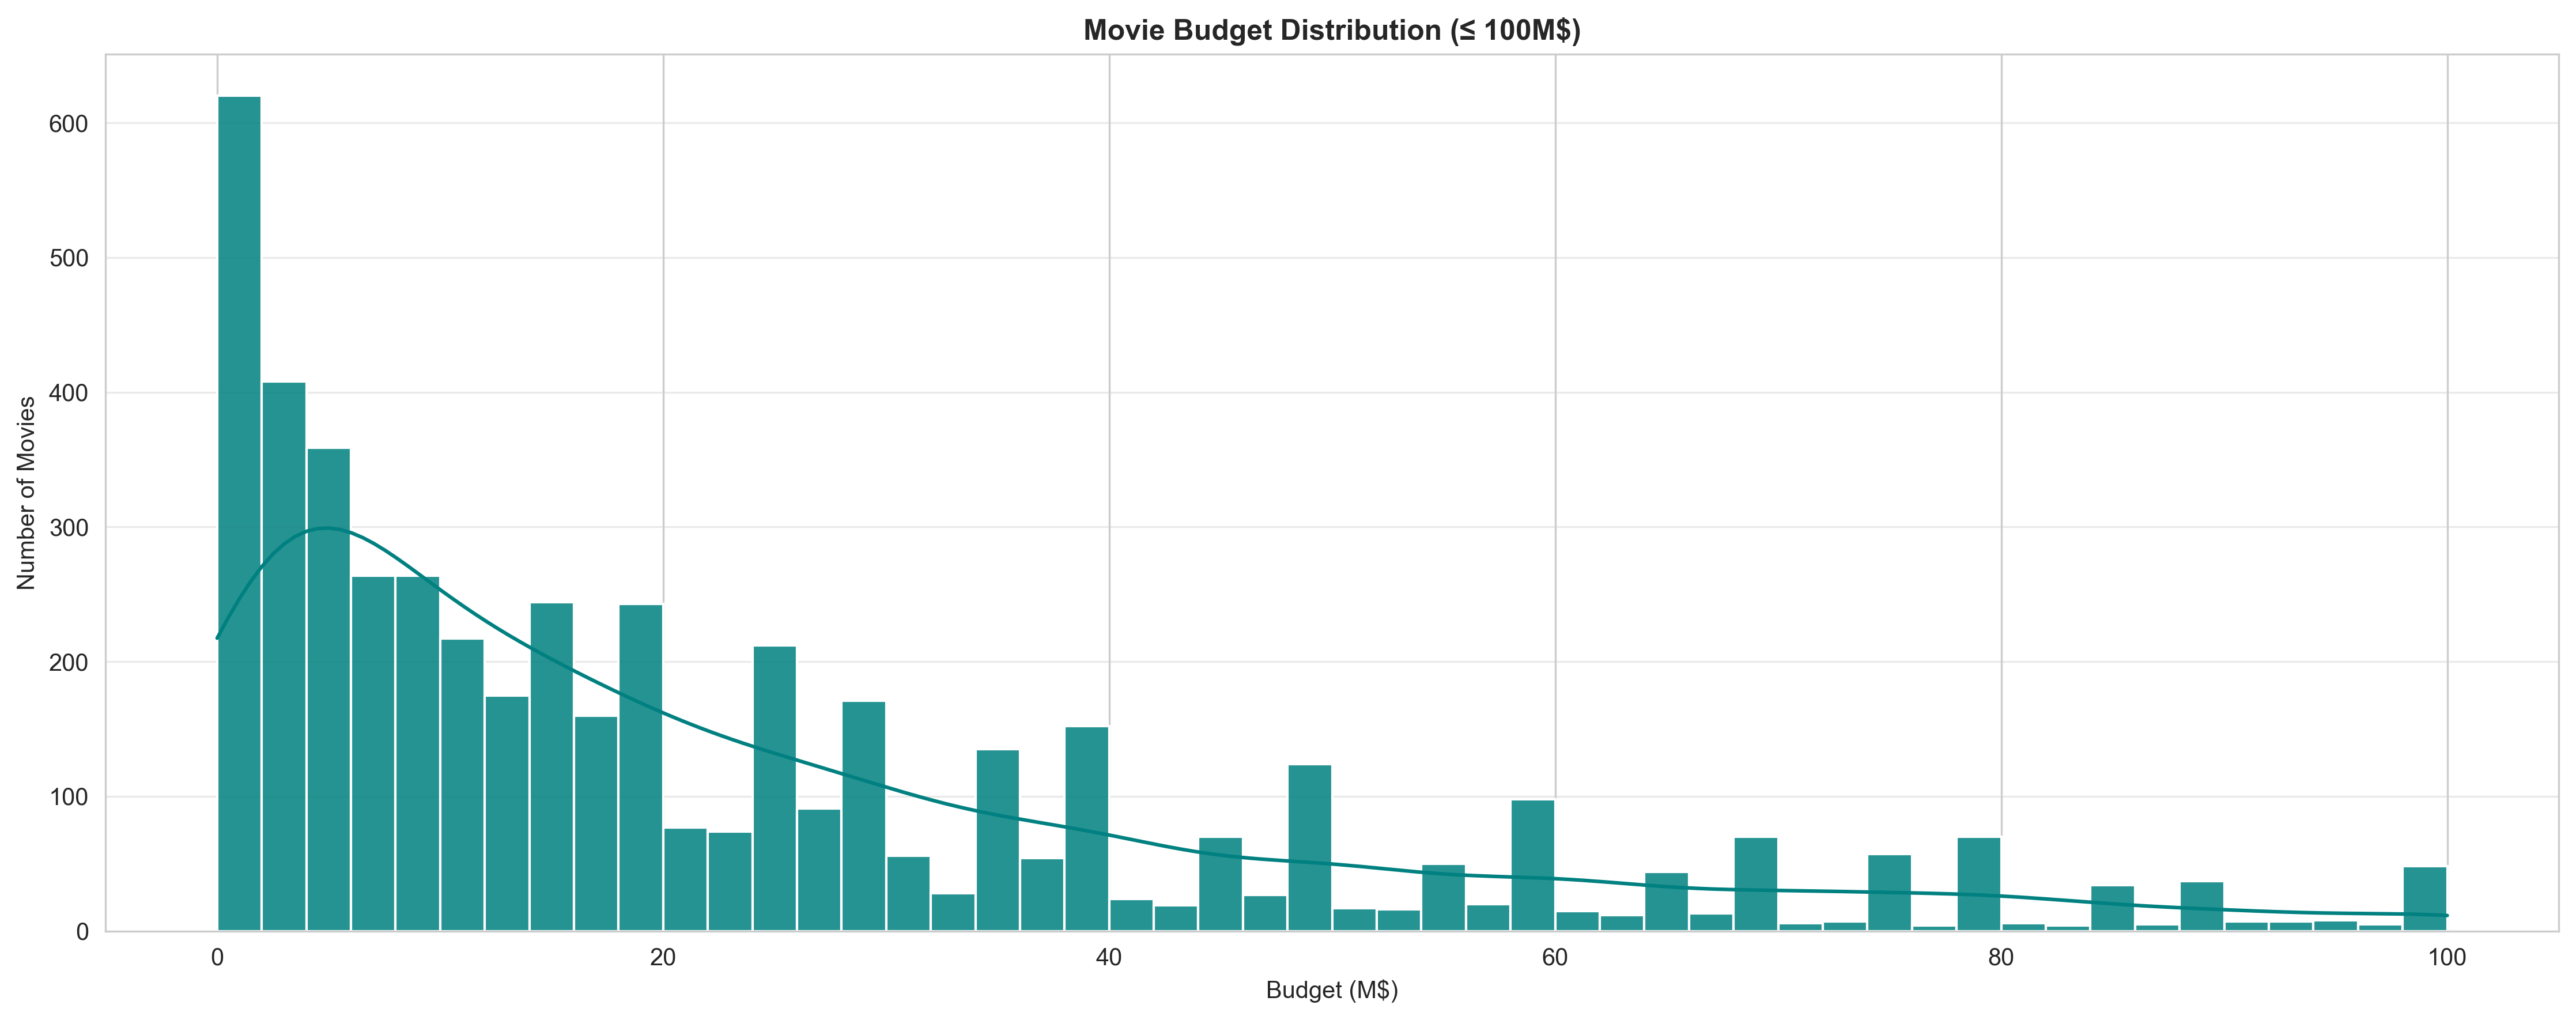

In [ ]:
max_budget_M = 100  
data_hist = df_analysis[df_analysis['budget_M'] <= max_budget_M]['budget_M']

plt.figure(figsize=(15, 6))
sns.histplot(data_hist, bins=50, color='teal', edgecolor='white', alpha=0.85, kde=True)
plt.title(f'Movie Budget Distribution (≤ {max_budget_M}M$)', fontweight='bold')
plt.xlabel('Budget (M$)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()




## 2. Median Budget Trend (1950–Present)
**Key Insight**: Steady increase; **accelerating after 2000**. Production costs keep rising over time.

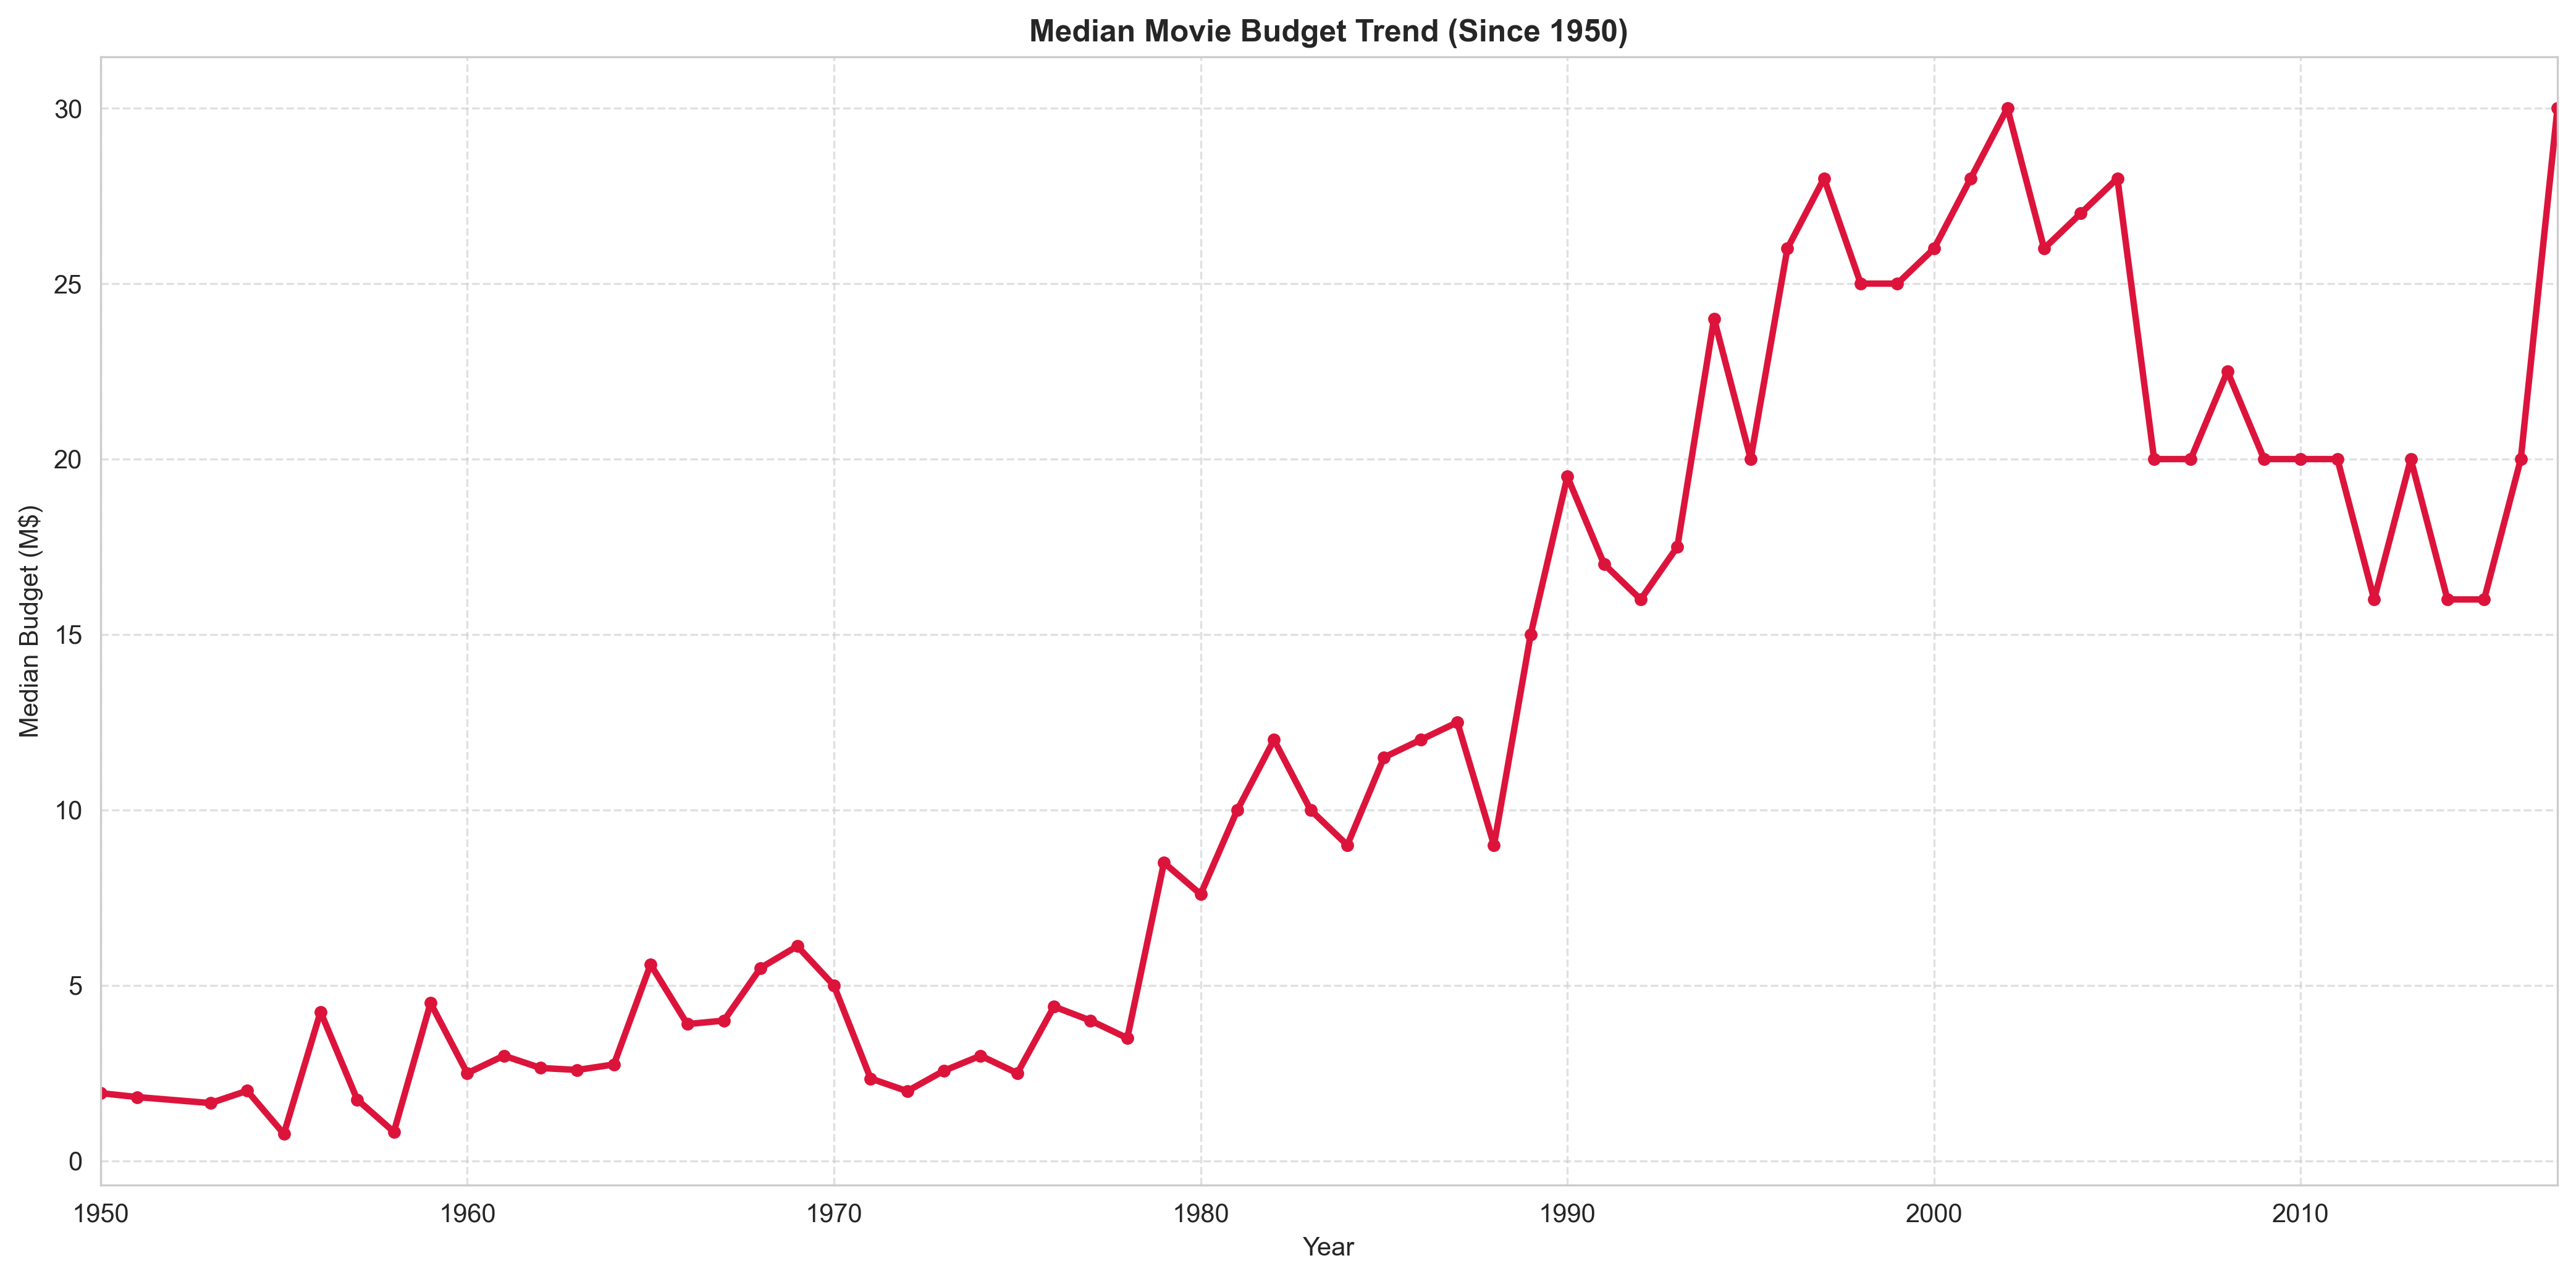

In [ ]:
budget_trend = df_analysis.groupby('release_year').agg(
    Median_Budget_M=('budget_M', 'median'),
    Sample_Count=('id', 'count')
).reset_index()

budget_trend = budget_trend[budget_trend['Sample_Count'] >= 5]

plt.figure(figsize=(14, 7))
plt.plot(budget_trend['release_year'], budget_trend['Median_Budget_M'],
         marker='o', linewidth=2.5, color='crimson', markersize=4)
plt.title('Median Movie Budget Trend (Since 1950)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Median Budget (M$)')
plt.xticks(np.arange(1950, budget_trend['release_year'].max() + 1, 10))
plt.xlim(1950, budget_trend['release_year'].max())
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




## 3. Budget vs Global Revenue Correlation
**Key Insight**: **Strong positive correlation (r ≈ 0.7–0.8)**. Higher budgets generally drive higher revenue.

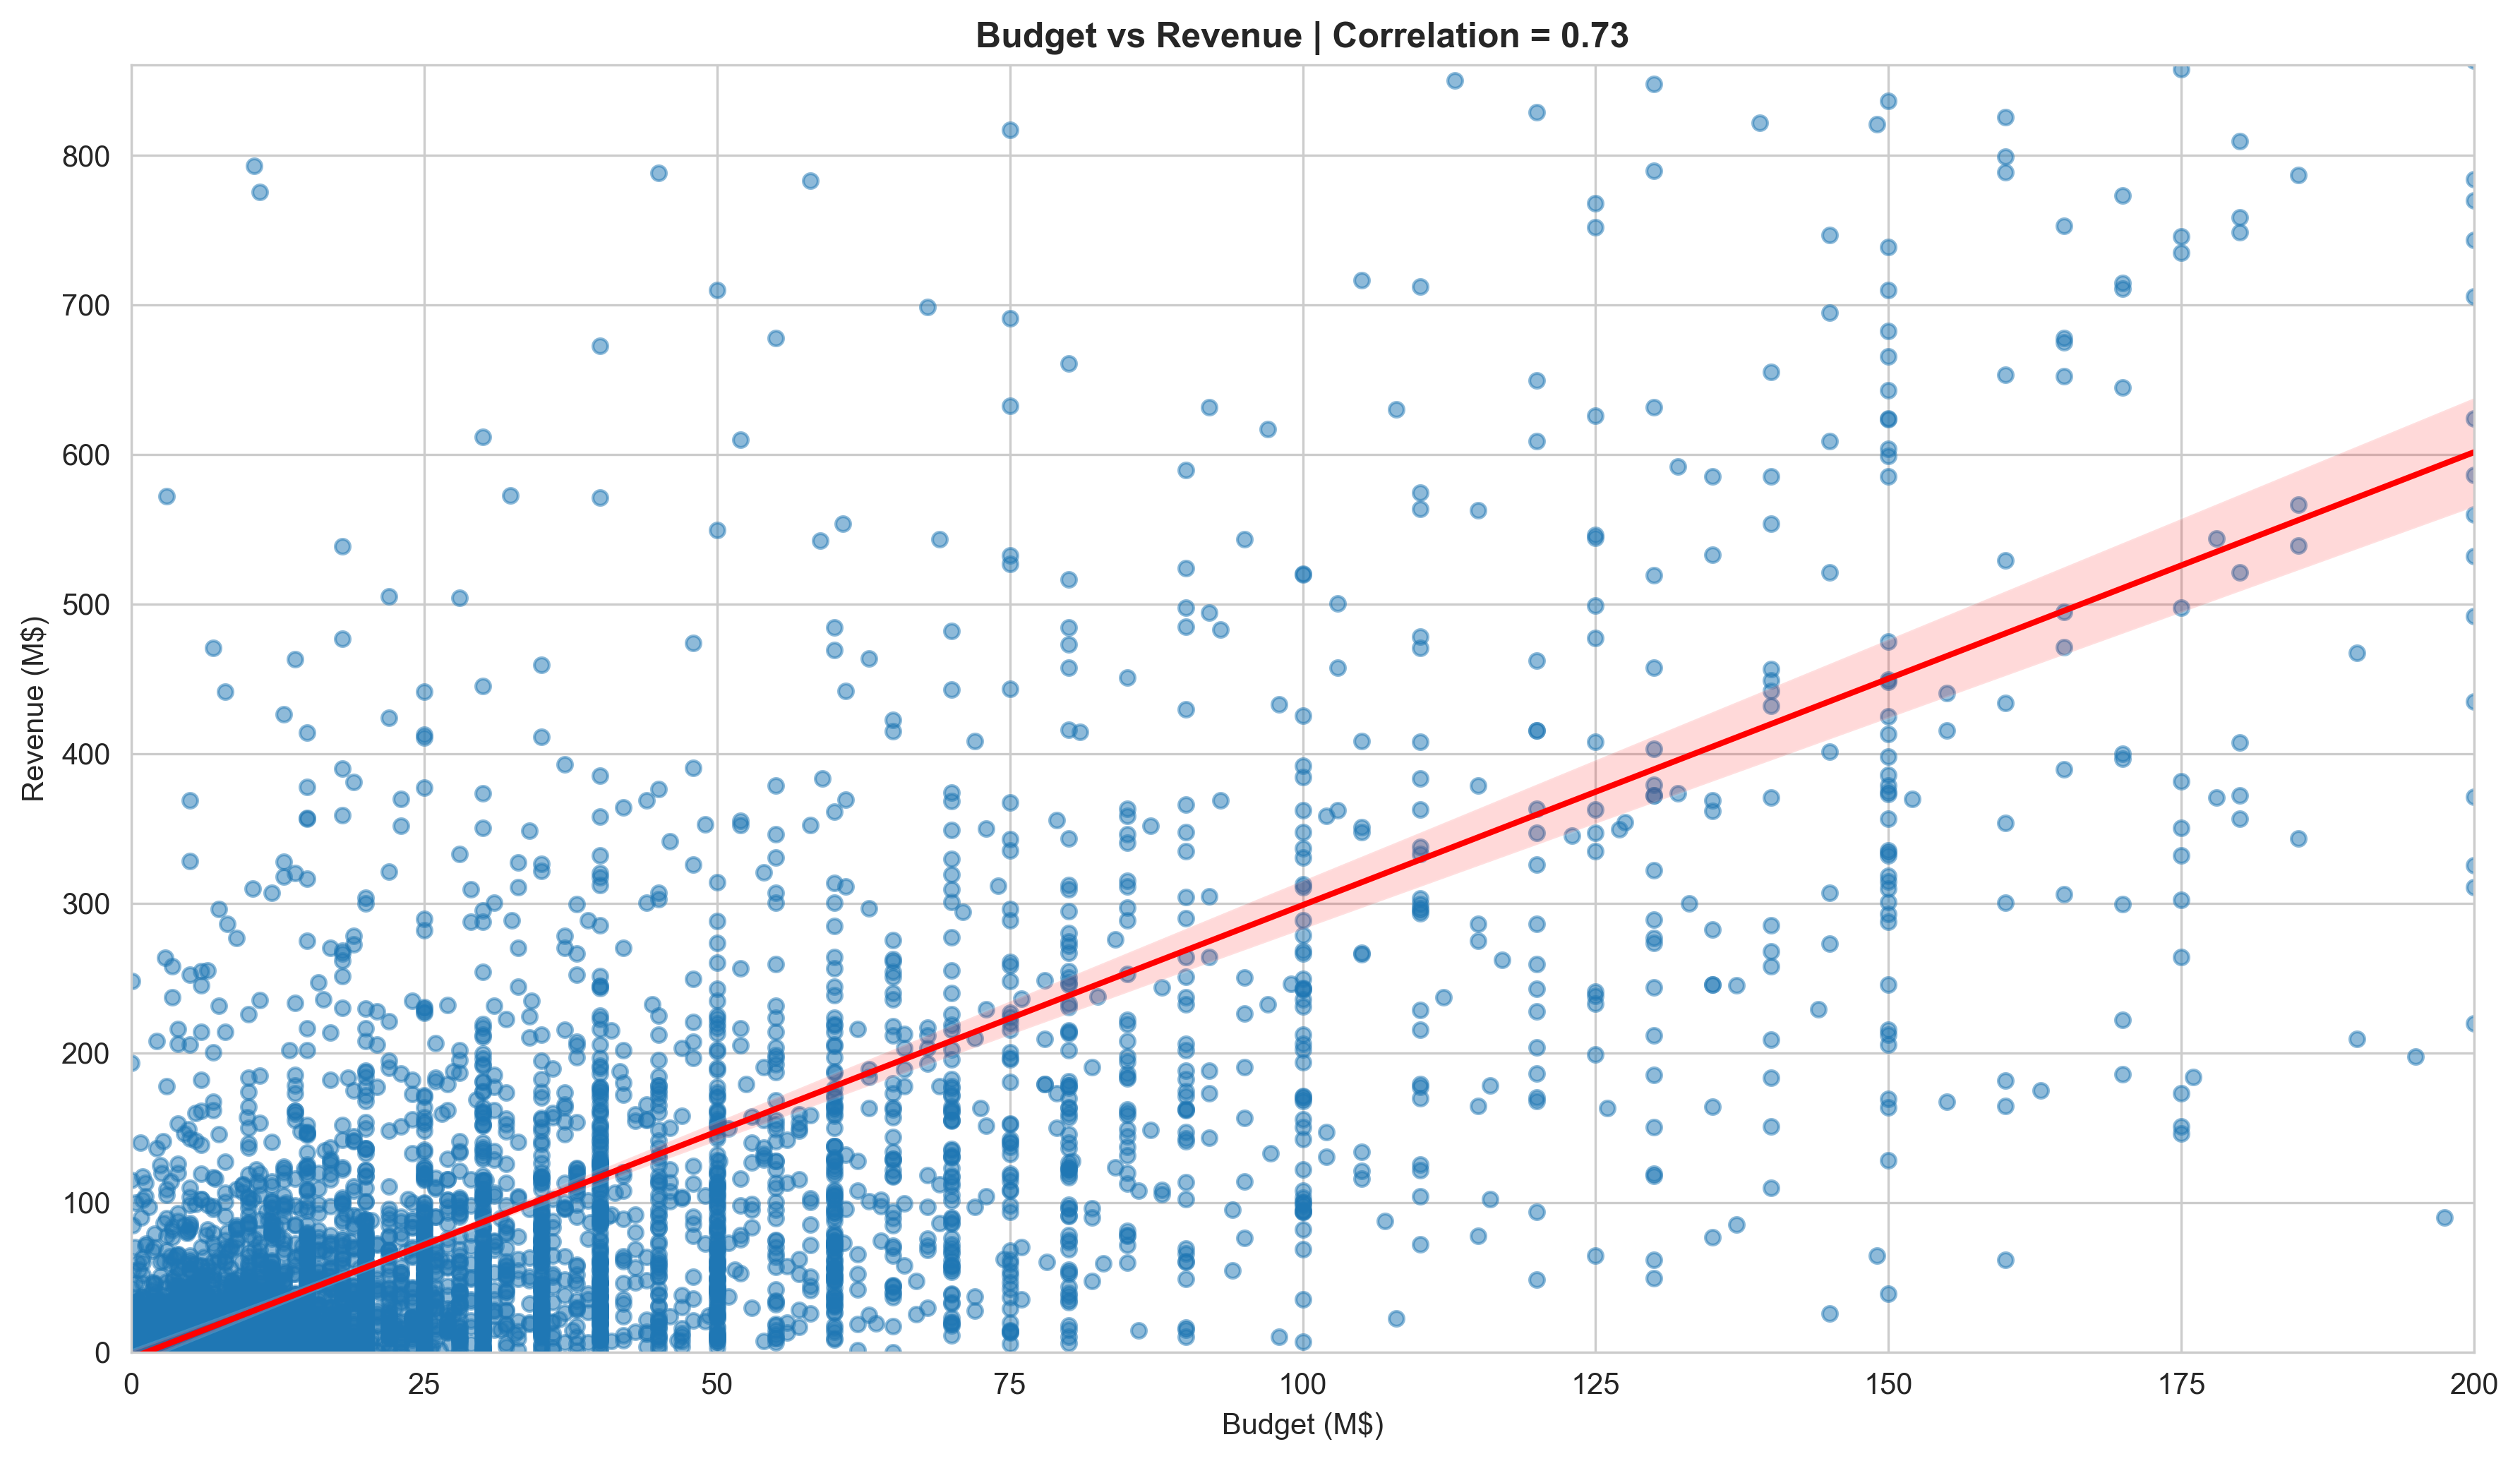

In [ ]:
plt.figure(figsize=(12,7))

sns.regplot(
    x='budget_M', y='revenue_M', data=df_analysis,
    scatter_kws={'alpha':0.5, 's':25},
    line_kws={'color':'red', 'linewidth':2},
    ci=95
)

corr = df_analysis['budget_M'].corr(df_analysis['revenue_M'])
plt.title(f'Budget vs Revenue | Correlation = {corr:.2f}', fontweight='bold')
plt.xlabel('Budget (M$)')
plt.ylabel('Revenue (M$)')

plt.xlim(0, df_analysis['budget_M'].quantile(0.99))
plt.ylim(0, df_analysis['revenue_M'].quantile(0.99))
plt.tight_layout()
plt.show()




## 4. Revenue Performance by Budget Tier
**Key Insight**: Revenue rises with budget, but **marginal returns diminish**. Mean > median: strong top-tail effect.

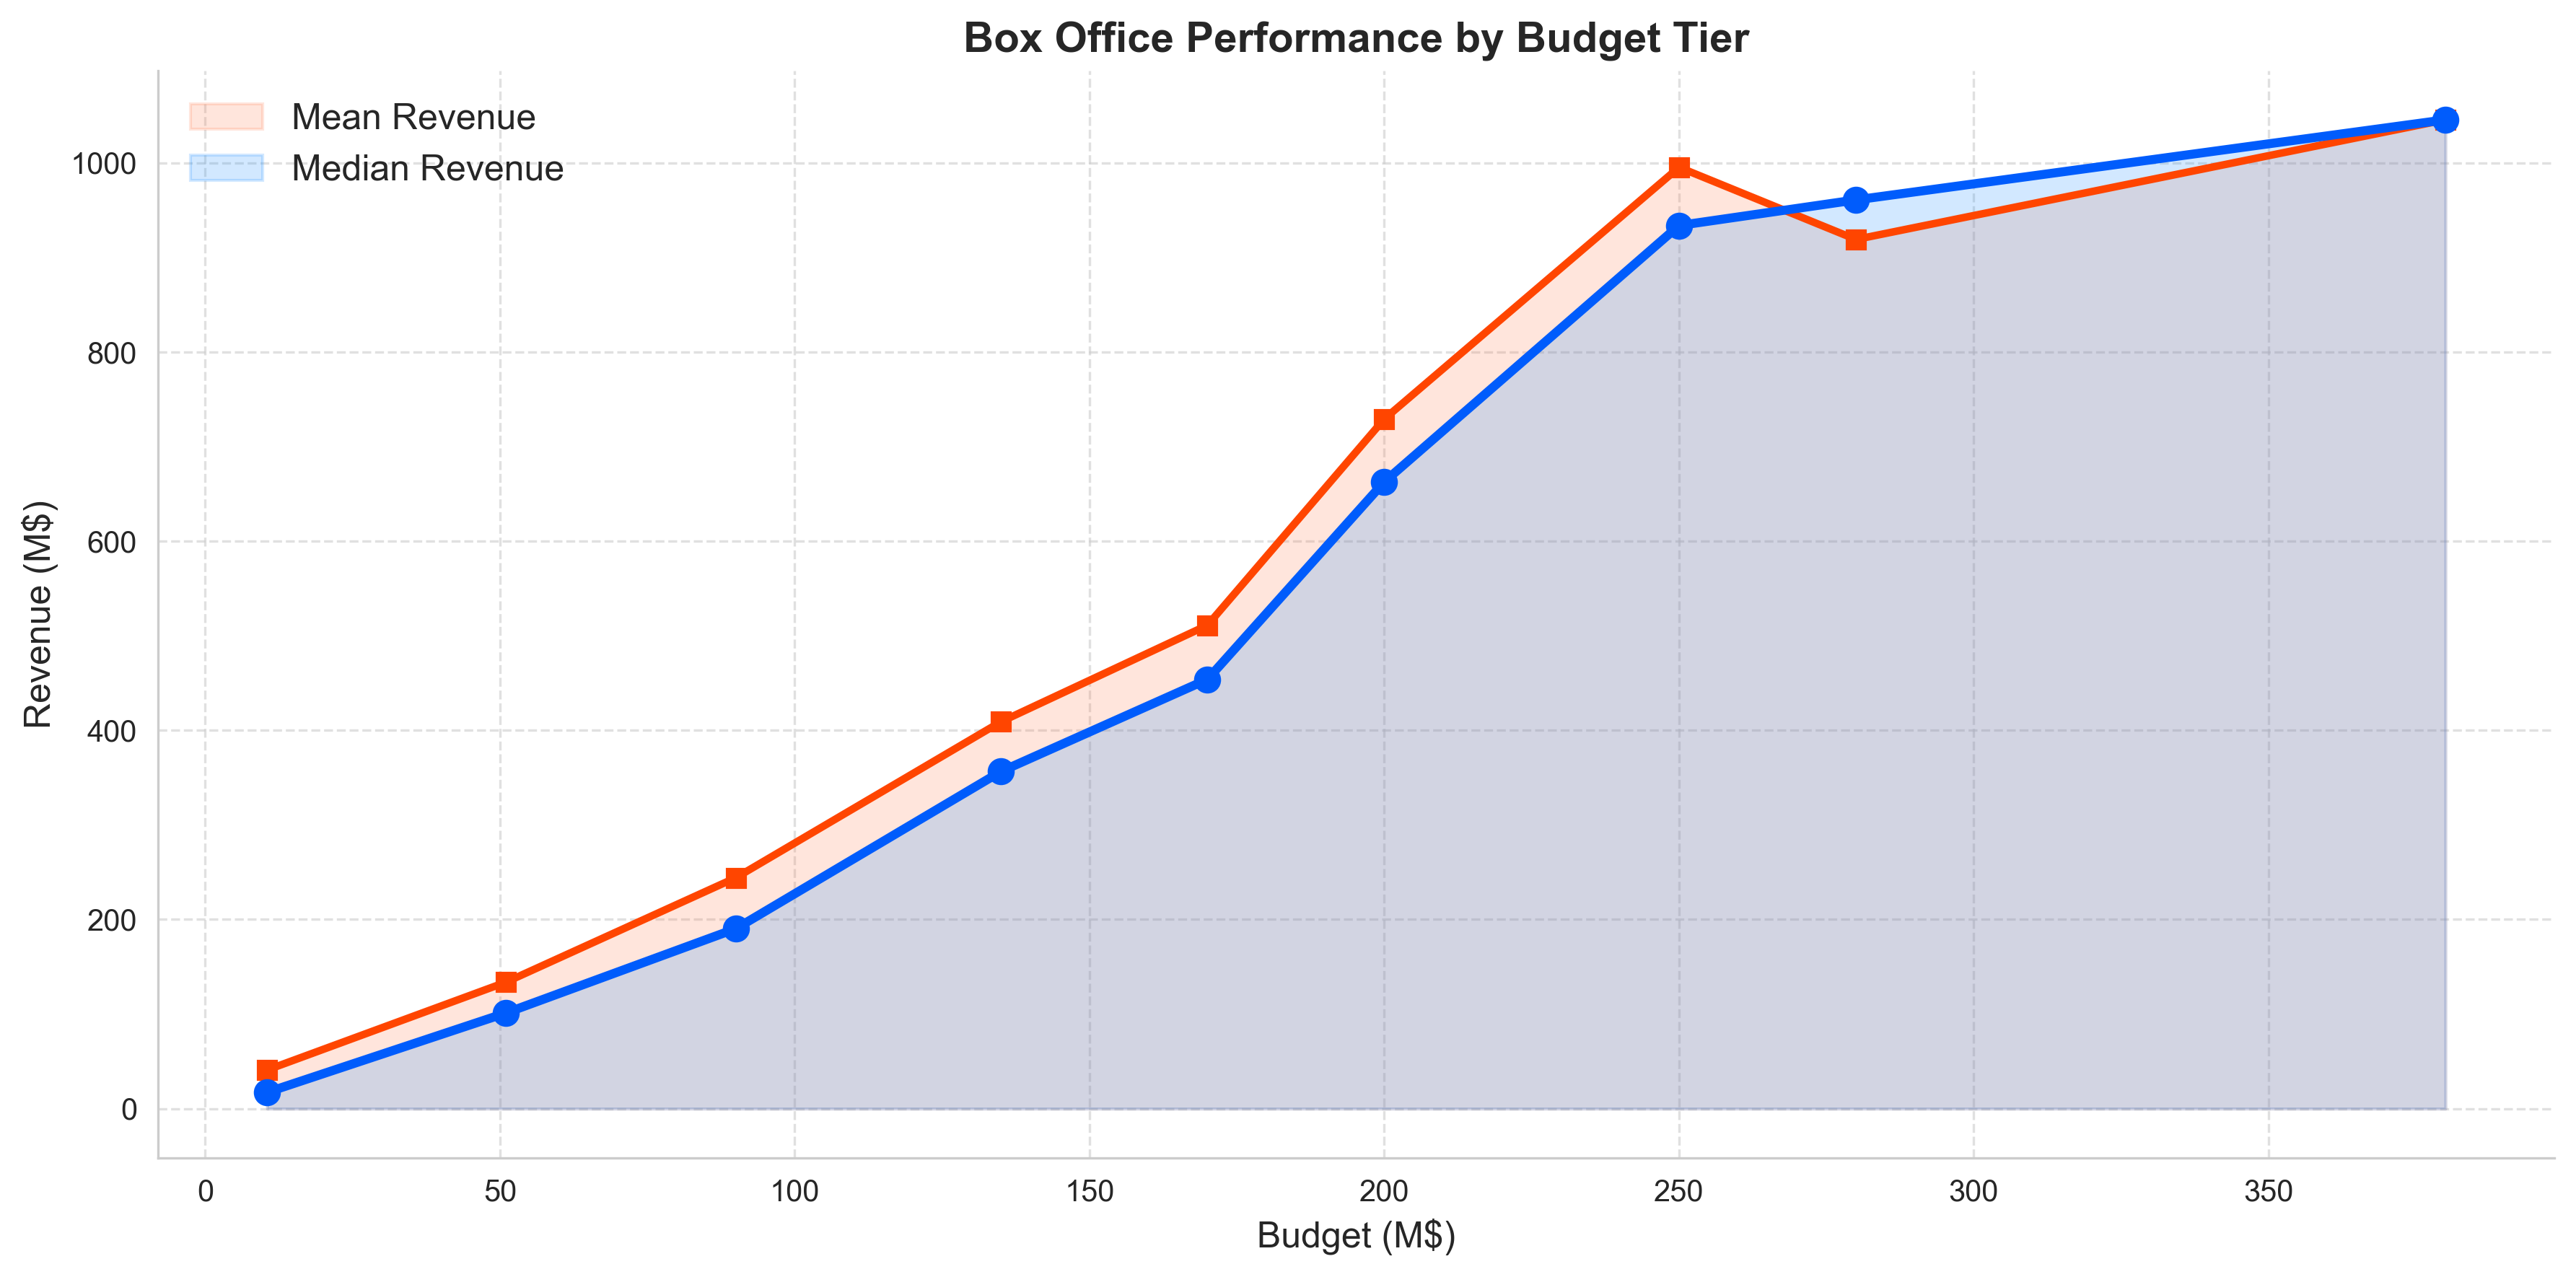

In [ ]:
budget_revenue_trend = df_analysis.groupby('budget_bin').agg(
    Median_Revenue_M=('revenue_M', 'median'),
    Mean_Revenue_M=('revenue_M', 'mean'),
    Sample_Count=('id', 'count')
).reset_index()
budget_revenue_trend = pd.merge(budget_revenue_trend, budget_mid, on='budget_bin')

plt.figure(figsize=(12, 6))


plt.fill_between(budget_revenue_trend['budget_M'], budget_revenue_trend['Mean_Revenue_M'],
                 color="#ff7f50", alpha=0.2, label="Mean Revenue")
plt.plot(budget_revenue_trend['budget_M'], budget_revenue_trend['Mean_Revenue_M'],
         color="#ff4500", linewidth=2.5, marker="s", markersize=6)

plt.fill_between(budget_revenue_trend['budget_M'], budget_revenue_trend['Median_Revenue_M'],
                 color="#1e90ff", alpha=0.2, label="Median Revenue")
plt.plot(budget_revenue_trend['budget_M'], budget_revenue_trend['Median_Revenue_M'],
         color="#005cfc", linewidth=3, marker="o", markersize=8)

plt.title('Box Office Performance by Budget Tier', fontweight='bold', fontsize=14)
plt.xlabel('Budget (M$)', fontsize=12)
plt.ylabel('Revenue (M$)', fontsize=12)
plt.legend(frameon=False, fontsize=12)
plt.grid(linestyle="--", alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()



## 5. Return on Investment (ROI) Distribution
**Key Insight**: Right-skewed; **over 50% profitable**. Strong dependence on blockbuster outliers.

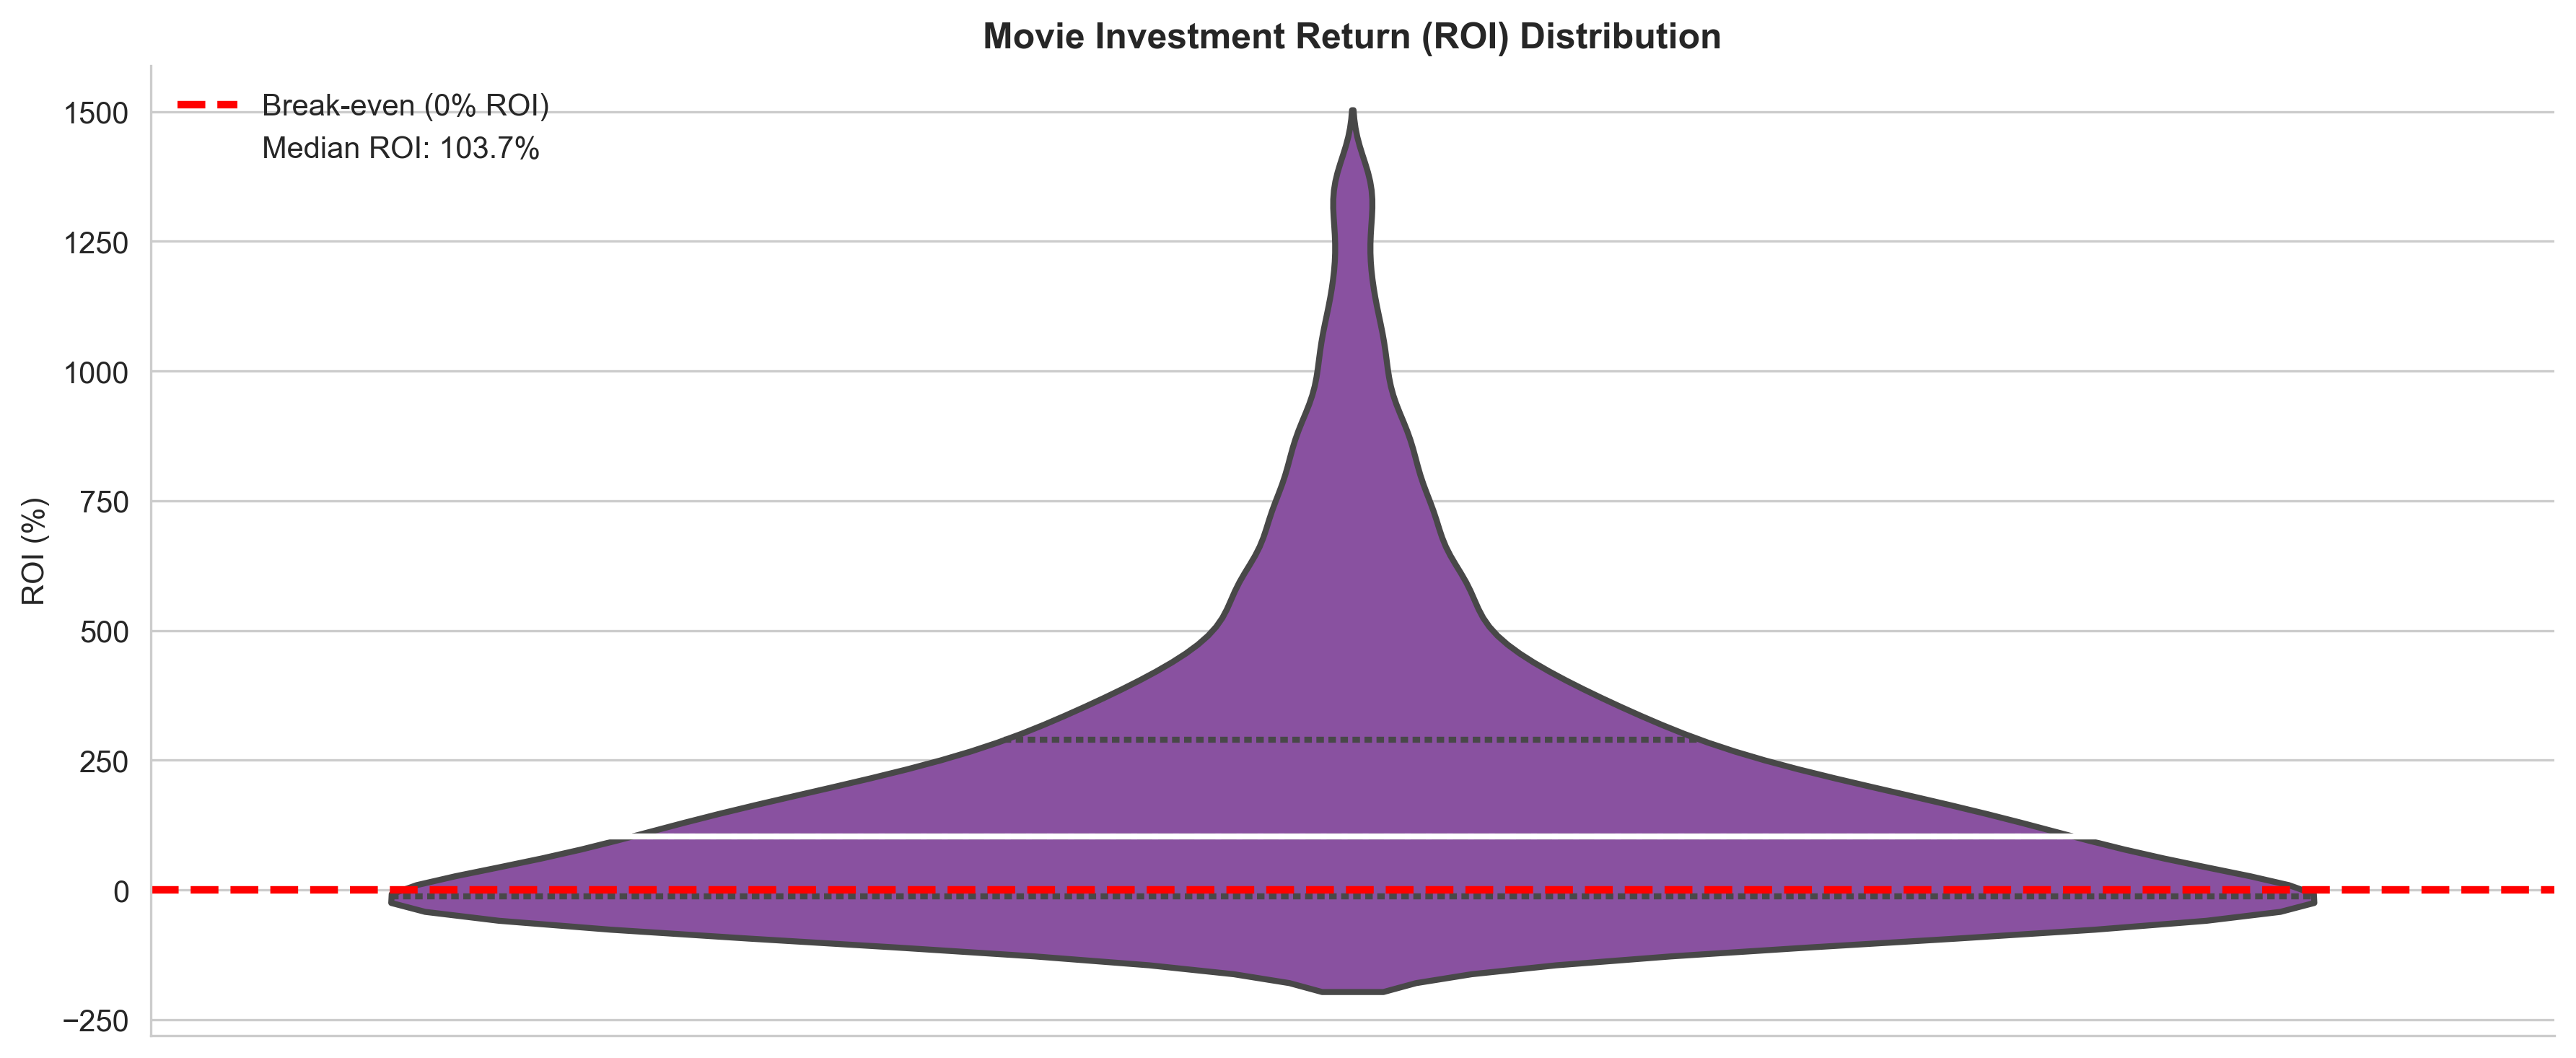

In [ ]:
max_roi_pct = df_analysis['ROI_pct'].quantile(0.95)
min_roi_pct = df_analysis['ROI_pct'].quantile(0.05)
roi_data = df_analysis[(df_analysis['ROI_pct'] >= min_roi_pct) & (df_analysis['ROI_pct'] <= max_roi_pct)]['ROI_pct']

plt.figure(figsize=(12, 5))


sns.violinplot(y=roi_data, color='#8e44ad', linewidth=2, inner='quartile')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Break-even (0% ROI)')
median_roi = roi_data.median()

plt.axhline(y=median_roi, color='white', linewidth=2, label=f'Median ROI: {median_roi:.1f}%')

plt.title('Movie Investment Return (ROI) Distribution', fontweight='bold')
plt.ylabel('ROI (%)')
plt.legend(frameon=False, loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()



## 6. ROI by Budget Tier (Profitability Ranking)
**Key Insight**: **$0–30M budget = highest ROI efficiency**. Higher budgets → lower ROI, higher risk.


 Budget Tier ROI Ranking (by Median ROI):
   budget_M  Median_ROI_pct   Mean_ROI_pct  Sample_Count
0     250.0      273.583679     302.312619            19
1     280.0      220.333333     222.369370             3
2     200.0      211.966666     258.235247            35
3     170.0      177.641220     198.032492            64
4     380.0      175.187843     175.187843             1
5     135.0      165.233341     201.160747           159
6      90.0      119.004442     165.949284           279
7      10.5       96.438504  556623.153670          3852
8      51.0       87.796689     146.584518           841


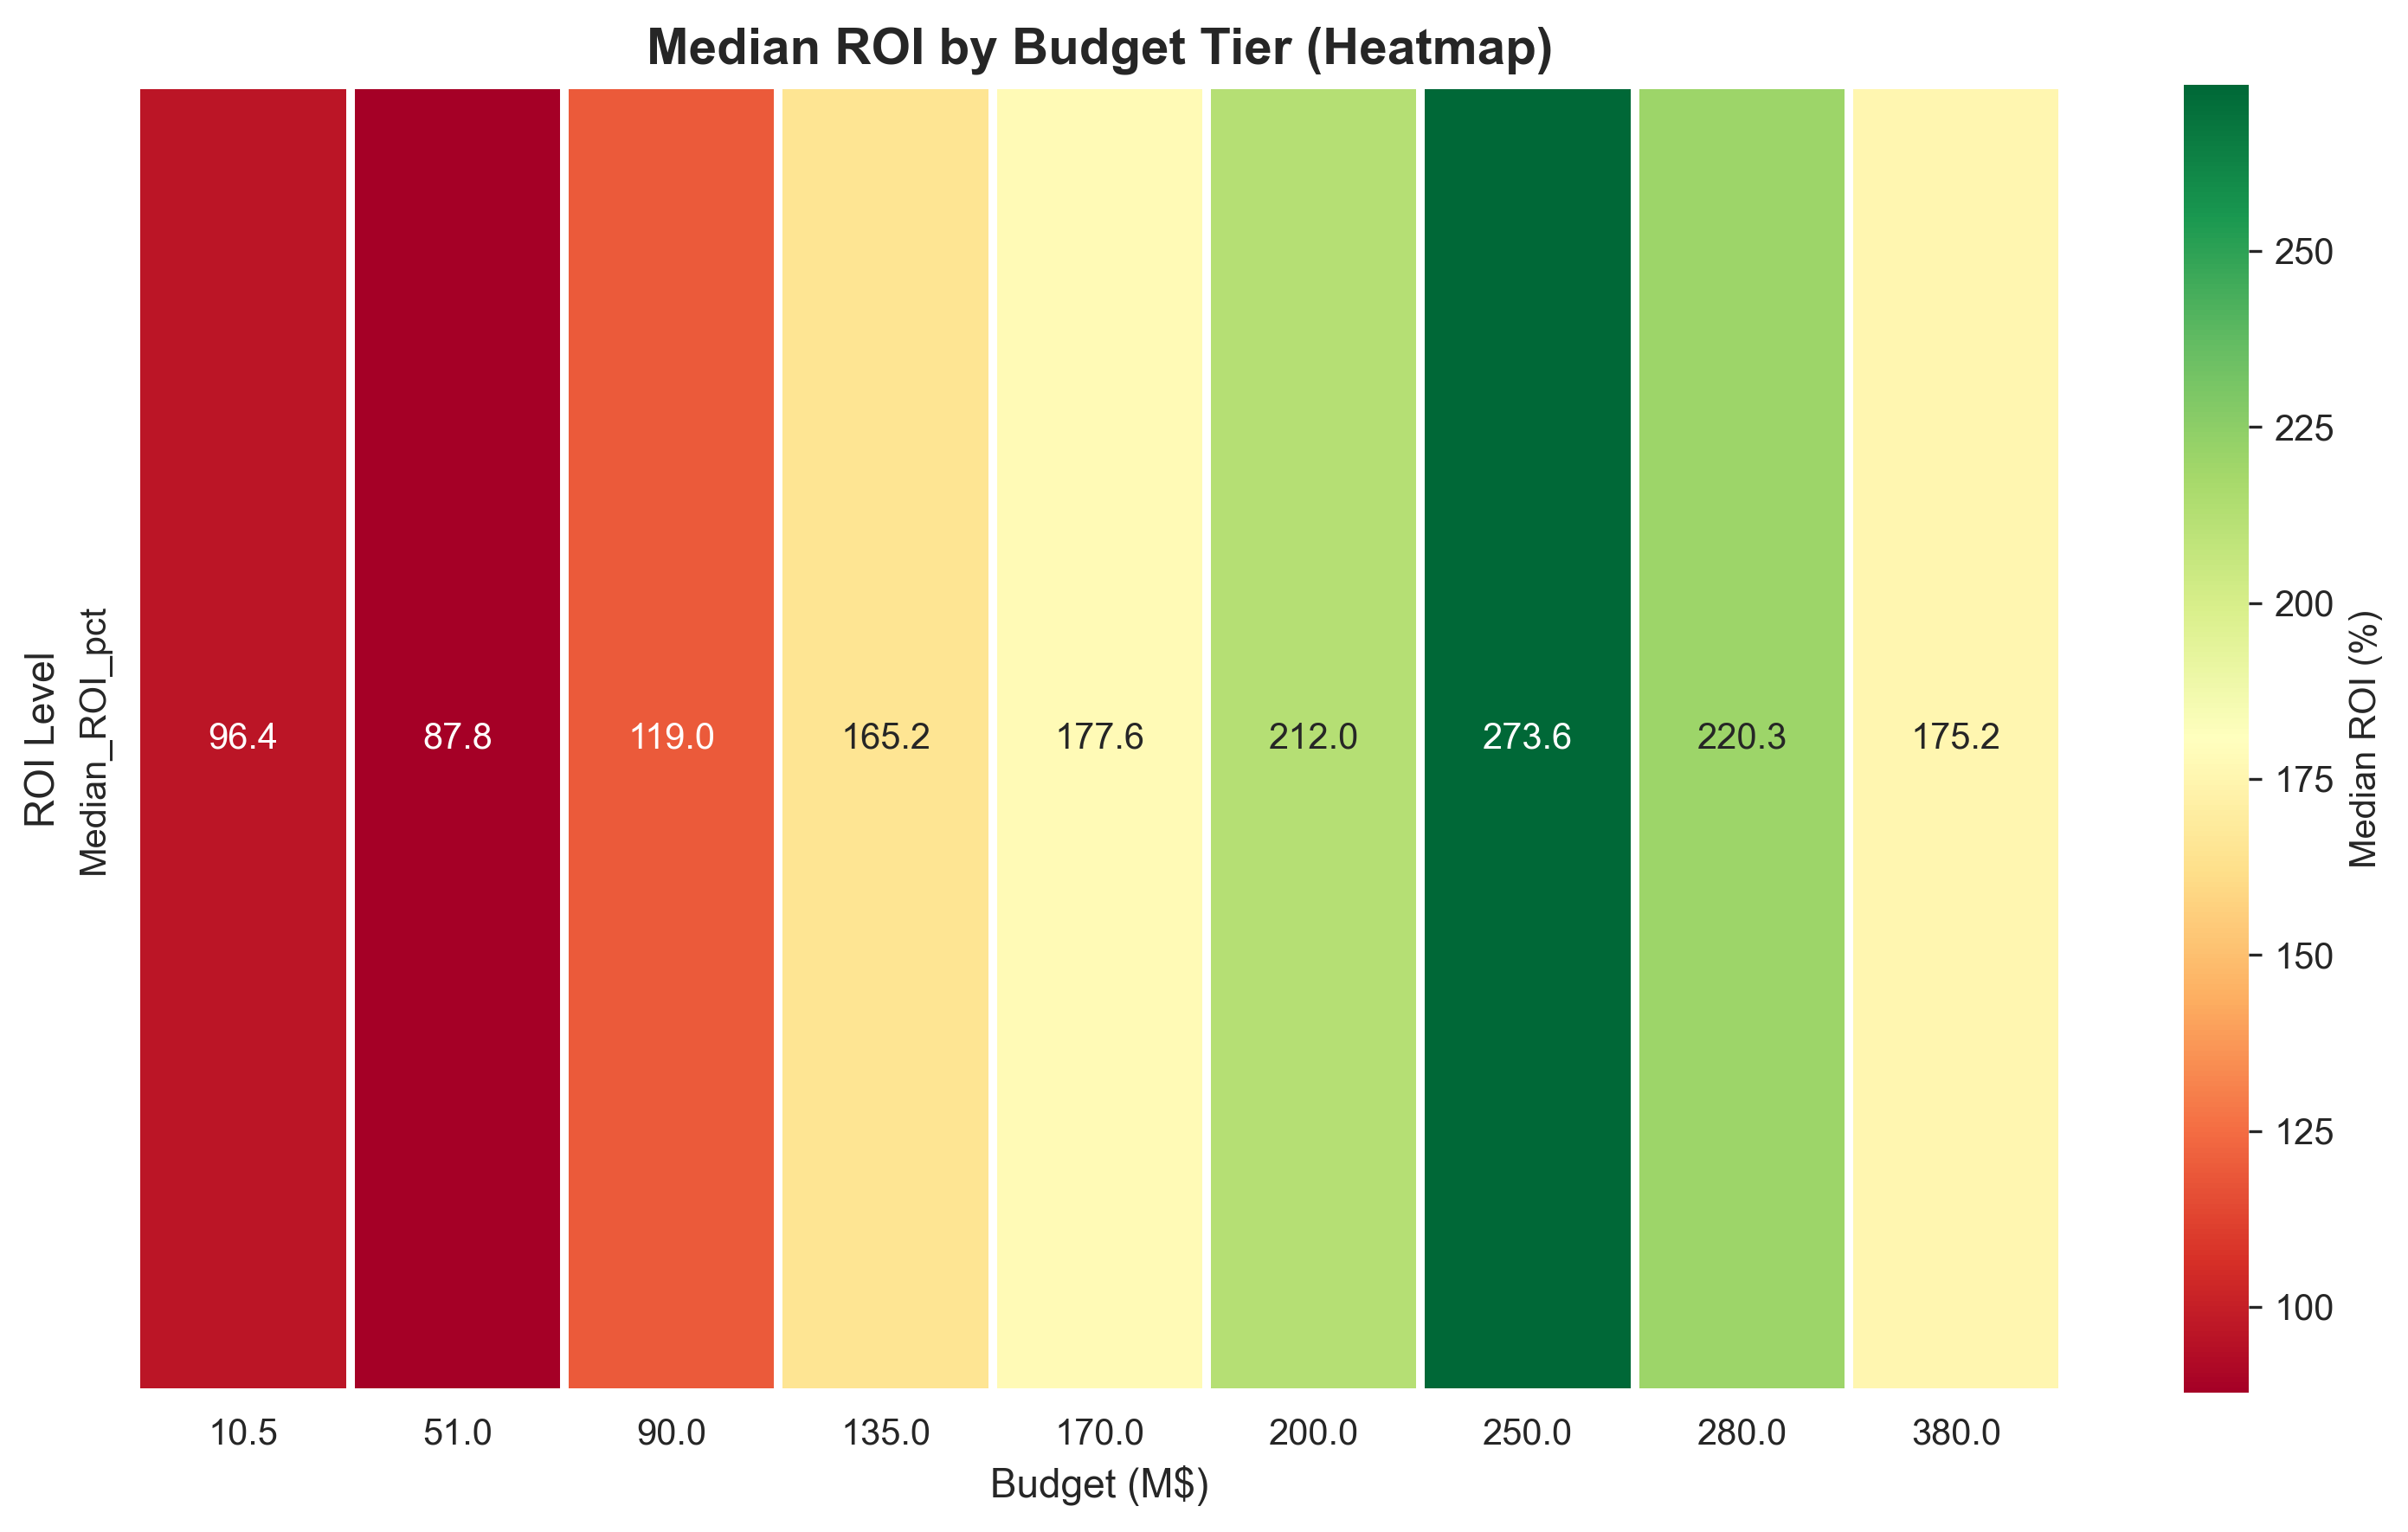

In [ ]:
budget_roi_trend = df_analysis.groupby('budget_bin').agg(
    Median_ROI_pct=('ROI_pct', 'median'),
    Mean_ROI_pct=('ROI_pct', 'mean'),
    Sample_Count=('id', 'count')
).reset_index()
budget_roi_trend = pd.merge(budget_roi_trend, budget_mid, on='budget_bin')

budget_roi_ranking = budget_roi_trend.sort_values('Median_ROI_pct', ascending=False).reset_index(drop=True)

print("\n Budget Tier ROI Ranking (by Median ROI):")
print(budget_roi_ranking[['budget_M', 'Median_ROI_pct', 'Mean_ROI_pct', 'Sample_Count']])


plt.figure(figsize=(10, 6))


heatmap_data = budget_roi_trend[['budget_M', 'Median_ROI_pct']].set_index('budget_M').T


sns.heatmap(
    heatmap_data,
    cmap='RdYlGn',       
    annot=True,          
    fmt='.1f', 
    linewidths=2,             
    cbar_kws={'label': 'Median ROI (%)'}
)

plt.title('Median ROI by Budget Tier (Heatmap)', fontweight='bold', fontsize=14)
plt.xlabel('Budget (M$)', fontsize=11)
plt.ylabel('ROI Level', fontsize=11)
plt.tight_layout()
plt.show()
